In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy import units as u
from astropy.io import fits
from astropy.table import Table
from astropy.wcs import WCS

import scopesim as sim
import scopesim_templates as sim_tp
import importlib.resources
import pathlib

py.warnings - WARNING: /Users/yashvi/Desktop/ZShooter/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



## Configure IRDB Path and log level

In [2]:
try:
    irdb_path = str(pathlib.Path(importlib.resources.files('irdb')).parent)
except ModuleNotFoundError:
    irdb_path = "/Users/yashvi/Desktop/ZShooter/irdb/"

sim.rc.__config__["!SIM.file.local_packages_path"] = irdb_path
sim.rc.__config__["!SIM.file.search_path"].append(irdb_path)

sim.utils.set_console_log_level("DEBUG")

## Create the simulator and configure it


In [3]:
cmd = sim.UserCommands(use_instrument="ZShooter_v2", set_modes=["SPEC"])
print(cmd)

CurrSys contents:
├─OBS:
│ ├─instrument: ZShooter_v2
│ ├─modes: ['SPEC']
│ ├─airmass: 1.2
│ ├─declination: 0
│ ├─hour_angle: 0
│ ├─pupil_angle: 0
│ ├─dit: 10
│ ├─ndit: 1
│ ├─mjdobs: 60920
│ ├─object: Test
│ ├─ra: 0.0
│ └─dec: 0.0
├─ATMO:
│ ├─background:
│ │ ├─filter_name: R
│ │ ├─value: 22.0
│ │ └─unit: mag
│ ├─spectrum:
│ │ └─filename: TER_maunakea_default.dat
│ ├─location: MaunaKea
│ ├─altitude: 4123
│ ├─longitude: -155.4744
│ ├─latitude: 19.8263
│ ├─temperature: -273
│ ├─humidity: 0.1
│ ├─pressure: 0.62
│ ├─pwv: 1.0
│ ├─airmass: !OBS.airmass
│ ├─pupil_angle: !OBS.pupil_angle
│ ├─pixel_scale: !INST.pixel_scale
│ └─seeing: 0.7
├─TEL:
│ ├─telescope: keck
│ └─temperature: !ATMO.temperature
├─INST:
│ ├─temperature: -80
│ ├─pixel_scale: 0.159574468085
│ ├─plate_scale: 10.638297872333334
│ ├─decouple_detector_from_sky_headers: True
│ └─dichroic_names: ['bgr-yjhk', 'b-gr', 'yj-hk', 'g-r', 'h-k']
├─DET:
│ ├─temperature: -120
│ ├─binx: 1
│ ├─biny: 1
│ ├─dit: !OBS.dit
│ └─ndit: !OBS.ndit
└─SIM

## Build the opical train

In [4]:
zs = sim.OpticalTrain(cmd)

astar.scopesim.effects.ter_curves - Loading dichroic bgr-yjhk from dichroics/TER_dichroic_bgr-yjhk.dat
astar.scopesim.effects.ter_curves - Loading dichroic b-gr from dichroics/TER_dichroic_b-gr.dat
astar.scopesim.effects.ter_curves - Loading dichroic yj-hk from dichroics/TER_dichroic_yj-hk.dat
astar.scopesim.effects.ter_curves - Loading dichroic g-r from dichroics/TER_dichroic_g-r.dat
astar.scopesim.effects.ter_curves - Loading dichroic h-k from dichroics/TER_dichroic_h-k.dat
astar.scopesim.optics.echelle - 
The spectrograph has been setup with the following properties:
	l0: 427.77751955647926 nm
	Orders: [66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89
 90 91]
	Focal length: 225.0 mm
	Incidence angle: 65.600 deg
	Reflectance angle: 65.60 deg

	Groove length: 0.02 mm
	# of pixels: 2028x2028
	Pixel size: 0.015 mm
	Pixels per res. element: 4.5
astar.scopesim.optics.echelle - 
The spectrograph has been setup with the following properties:
	l0: 615.7741780934598 nm


Check that FoV's are defined as expected. We'll load the trace list FITS being used and match the number of trace_ids per image plane to the number of FoV's in that image plane.

In [5]:
# Load the trace list FITS being used
hdul = fits.open(f"{irdb_path}/ZShooter_v2/traces/analytical_echelle_traces.fits")
ecat = Table(hdul[1].data) # Table containing list of trace_ids and their corresponding aperture_id and image_plane_id
print(f"Trace list contains {len(ecat)} traces.")
print(f"Number of traces per image plane: {np.unique(list(ecat['image_plane_id']), return_counts=True)}")

Trace list contains 120 traces.
Number of traces per image plane: (array([0, 1, 2, 3, 4, 5]), array([26, 26, 22, 25, 12,  9]))


In [6]:
fovs = zs.fov_manager.fovs
print(f"Unique FoV image planes: {np.unique([fv.meta['image_plane_id'] for fv in fovs], return_counts=True)}")
# It is ok if some are off by one, those are traces at the edgees that get cutoff by the dichroic settings.

astar.scopesim.optics.fov_manager - Returning existing fovs_list.
Unique FoV image planes: (array([0, 1, 2, 3, 4, 5]), array([26, 25, 21, 24, 12,  9]))


## Tweak what effects are included if desired

In [7]:
# for effect in ['maunakea_atmospheric_transmission','seeing_psf','telescope_reflection','Selector','trace_eff','detector_qe']:
#     zs[effect].include = False
zs.effects

element,name,class,included
str15,str33,str25,bool
MaunaKea,maunakea_atmospheric_transmission,TERCurve,True
MaunaKea,seeing_psf,SeeingPSF,True
keck,telescope_reflection,SurfaceList,True
ZShooter,Selector,SurfaceList,True
ZShooter,dichroic_tree,DichroicTree,True
ZShooter,slitwheel_selector,SelectorWheel,True
ZShooter,trace_eff_analytical,EchelleSpectralEfficiency,True
ZShooter,trace_list_analytical,EchelleSpectralTraceList,True
zspec_detectors,detector_b,DetectorList,True


# Make and plot sources

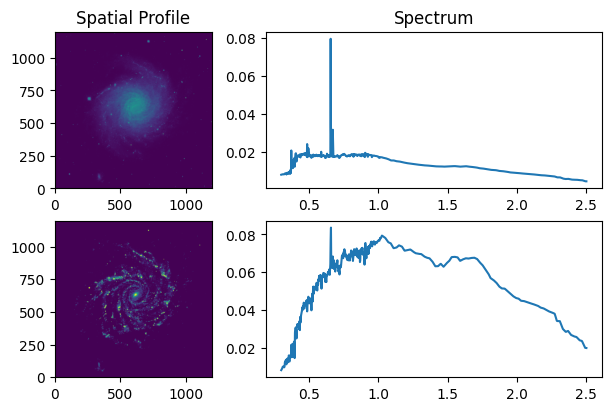

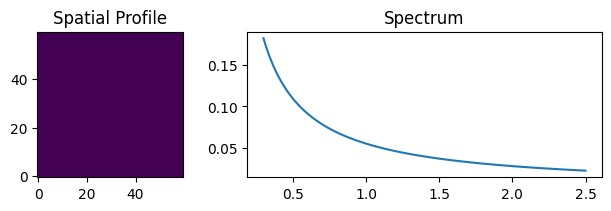

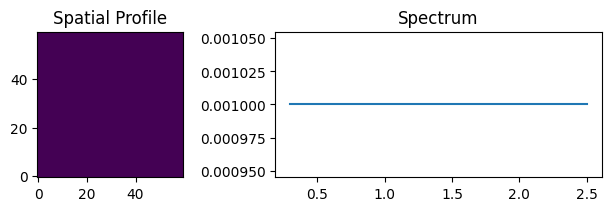

In [28]:
def plot_source(source):
    wave = np.linspace(0.3, 2.5, 1001) * u.um
    num_fields = len(source.fields)
    fig, axs = plt.subplots(figsize=(6,2*num_fields), nrows=num_fields, ncols=2, width_ratios=[1,2], constrained_layout=True)
    if num_fields == 1:
        axs = np.array([axs])
    for i, field in enumerate(source.fields):
        ax1, ax2 = axs[i]
        ax1.imshow(field.data, origin='lower', cmap='viridis')
        ax2.plot(wave, field.spectrum(wave))
        if i==0:
            ax1.set_title('Spatial Profile')
            ax2.set_title('Spectrum')

# Galaxy
gal = sim_tp.extragalactic.galaxies.spiral_two_component(extent=200*u.arcsec, fluxes=(15, 15)*u.mag)
gal.shift(dy=-30*0.004)
plot_source(gal)

# Uniformly source with const AB mag
from scopesim.source.source_templates import ab_spectrum, uniform_source
flatsp = ab_spectrum(mag=10)
flat1 = uniform_source(flatsp, extent=60)
plot_source(flat1)

# Uniformly illuminated source with a const photon flux density of 1 photon/s/cm^2/Angstrom
from scopesim.source.source_templates import ConstFlux1D, SourceSpectrum, Empirical1D
waves = np.geomspace(100, 300000, 50000)
sp = ConstFlux1D(amplitude=0.001) # default unit is photon/s/cm^2/Angstrom
flatsp = SourceSpectrum(Empirical1D, points=waves, lookup_table=sp(waves))
flat2 = uniform_source(flatsp, extent=60)
plot_source(flat2)


## Simulate it!

In [29]:
zs.observe(flat2, update=True) ## observes empty sky if no source is given

astar.scopesim.optics.fov_manager - Generating initial fovs_list.
astar.scopesim.effects.psfs.psf_base - Executing seeing_psf, FoV setup
astar.scopesim.effects.ter_curves - Executing dichroic_tree, FoV setup
astar.scopesim.effects.ter_curves - Created 1 FoVs for aperture_id 0
astar.scopesim.effects.ter_curves - Created 1 FoVs for aperture_id 1
astar.scopesim.effects.ter_curves - Created 1 FoVs for aperture_id 2
astar.scopesim.effects.ter_curves - Created 1 FoVs for aperture_id 3
astar.scopesim.effects.ter_curves - Created 1 FoVs for aperture_id 4
astar.scopesim.effects.ter_curves - Created 1 FoVs for aperture_id 5
astar.scopesim.effects.selector_wheel - Applying effect for aperture_id: 0 -> SlitWheel: "<empty> : [ubvis_one_arcsec]", volumes: 1
astar.scopesim.effects.apertures - Executing ubvis_one_arcsec, FoV setup
astar.scopesim.effects.selector_wheel - Applying effect for aperture_id: 1 -> SlitWheel: "<empty> : [ubvis_one_arcsec]", volumes: 1
astar.scopesim.effects.apertures - Execut

 FOVs:   0%|          | 0/117 [00:00<?, ?it/s]

astar.scopesim.optics.fov - 4 fields in FOV
astar.scopesim.optics.fov - old naxis: [60, 60]
astar.scopesim.optics.fov - Found 'deg' in image WCS, applying 360 fix.
astar.scopesim.optics.fov - XY HDU:
[[ 0.00833333 -0.00833333]
 [ 0.00833333  0.00833333]
 [-0.00833333  0.00833333]
 [-0.00833333 -0.00833333]]
astar.scopesim.optics.fov - XY FOV:
[[-0.00140366 -0.00012707]
 [-0.00140366  0.00013889]
 [ 0.00138889  0.00013889]
 [ 0.00138889 -0.00012707]]
astar.scopesim.optics.fov - xy0s: [-0.00140366 -0.00012707]; xy1s: [0.00138889 0.00013889]
astar.scopesim.optics.fov - xyp:
[[34.5531915 29.0425532]
 [24.5       30.       ]]
astar.scopesim.optics.fov - xyp:
[[24.5       29.0425532]
 [34.5531915 30.       ]]
astar.scopesim.optics.fov - xy0p: [24 29]; xy1p: [35 30]
astar.scopesim.optics.fov - xy0p: [24 29]; xy1p: [35 30]



 FOV effects:   0%|          | 0/5 [00:00<?, ?it/s]

astar.scopesim.effects.psfs.psf_base - Executing seeing_psf, convolution
astar.scopesim.effects.psfs.psf_base - PSF convolution start
astar.scopesim.effects.psfs.psf_base - PSF convolution done
astar.scopesim.effects.ter_curves - Executing dichroic_tree, observe
astar.scopesim.effects.spectral_trace_list - trace_list_analytical applied to FieldOfView3D
astar.scopesim.effects.spectral_trace_list_utils - Mapping b_66
astar.scopesim.effects.spectral_trace_list - trace_list_analytical done


...


 FOV effects:   0%|          | 0/5 [00:00<?, ?it/s]

astar.scopesim.effects.psfs.psf_base - Executing seeing_psf, convolution
astar.scopesim.effects.psfs.psf_base - PSF convolution start
astar.scopesim.effects.psfs.psf_base - PSF convolution done
astar.scopesim.effects.ter_curves - Executing dichroic_tree, observe
astar.scopesim.effects.spectral_trace_list - trace_list_analytical applied to FieldOfView3D
astar.scopesim.effects.spectral_trace_list_utils - Mapping k_39
astar.scopesim.effects.spectral_trace_list - trace_list_analytical done


 FOV effects: 100%|██████████| 5/5 [00:00<00:00, 174.03it/s]

astar.scopesim.optics.image_plane - No BUNIT found in added HDU.



 FOVs: 100%|██████████| 117/117 [00:09<00:00, 12.65it/s]


#### Read it out

In [30]:
hdul = zs.readout()

astar.scopesim.optics.optical_train - exptime: None given in kwargs, put in !OBS
astar.scopesim.optics.optical_train - dit: 10 given in kwargs, put in !OBS
astar.scopesim.optics.optical_train - ndit: 1 given in kwargs, put in !OBS
astar.scopesim.detector.detector_manager - Extracting from 1 detectors...
astar.scopesim.effects.electronic - ExposureIntegration.: DIT = 10 s, NDIT = 1
astar.scopesim.effects.selector_wheel - Since passed object is a Detector, selector_key by default is the ID of the Detector object.
astar.scopesim.effects.selector_wheel - Since passed object is a Detector, selector_key by default is the ID of the Detector object.
astar.scopesim.effects.selector_wheel - Since passed object is a Detector, selector_key by default is the ID of the Detector object.
astar.scopesim.detector.detector_manager - Extracting from 1 detectors...
astar.scopesim.effects.electronic - ExposureIntegration.: DIT = 10 s, NDIT = 1
astar.scopesim.effects.selector_wheel - Since passed object is a

In [31]:
hdul

[[<astropy.io.fits.hdu.image.PrimaryHDU object at 0x116efda00>, <astropy.io.fits.hdu.image.ImageHDU object at 0x1172b7aa0>],
 [<astropy.io.fits.hdu.image.PrimaryHDU object at 0x1253b4d10>, <astropy.io.fits.hdu.image.ImageHDU object at 0x1253b6750>],
 [<astropy.io.fits.hdu.image.PrimaryHDU object at 0x115f24770>, <astropy.io.fits.hdu.image.ImageHDU object at 0x1253b7620>],
 [<astropy.io.fits.hdu.image.PrimaryHDU object at 0x1253b49e0>, <astropy.io.fits.hdu.image.ImageHDU object at 0x1253b5640>],
 [<astropy.io.fits.hdu.image.PrimaryHDU object at 0x125311dc0>, <astropy.io.fits.hdu.image.ImageHDU object at 0x1253105c0>],
 [<astropy.io.fits.hdu.image.PrimaryHDU object at 0x125313440>, <astropy.io.fits.hdu.image.ImageHDU object at 0x116efeb10>]]

## Show it

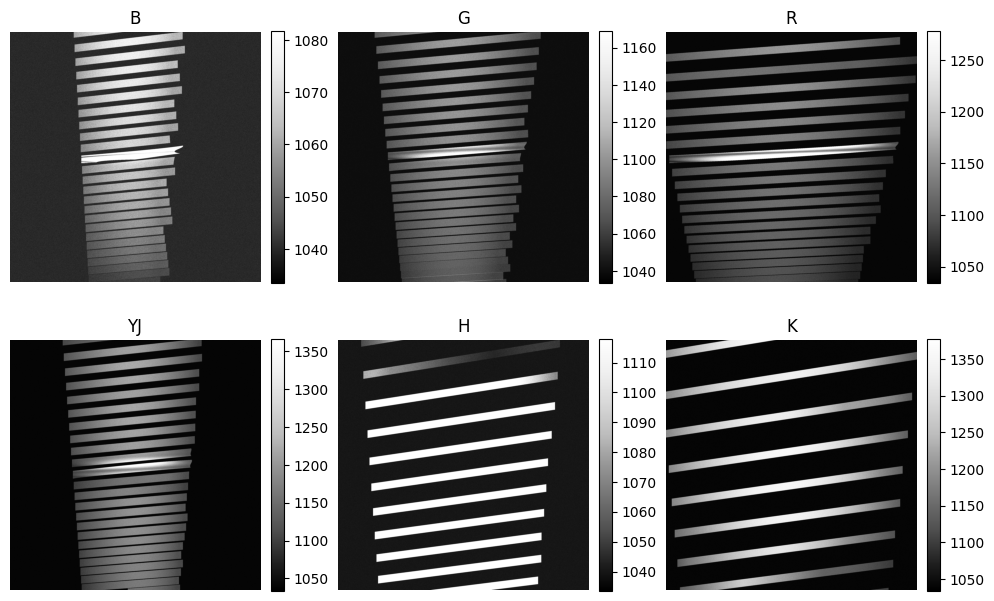

In [32]:
from astropy.visualization import ZScaleInterval

# reduce space between subplots
fig, axes = plt.subplots(2,3, figsize=(12,8), gridspec_kw={'wspace':0.2}, tight_layout=True)
titles = ['B', 'G', 'R', 'YJ', 'H', 'K']
i = 0
for ax, imhdu in zip(axes.flat, hdul):
    interval = ZScaleInterval()
    vmin, vmax = interval.get_limits(imhdu[1].data)
    ax.axis("off")
    im = ax.imshow(imhdu[1].data, origin='lower', vmin=vmin, vmax=vmax, cmap='Grays_r')
    ax.set_title(titles[i])
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    imhdu.writeto(f"{irdb_path}/ZShooter_v2/zspec_{titles[i]}.fits", overwrite=True)
    i += 1

plt.subplots_adjust(wspace=0.0, hspace=0.0)
plt.savefig(f"{irdb_path}/ZShooter_v2/zspec_echellogram.png", dpi=300)


### Debugging

In [ ]:
spt = zs['trace_list']

In [ ]:
traces = spt.spectral_traces

In [ ]:
fig, ax = plt.subplots(1,1,figsize=(12,12))
ubtraces = {}
for key in traces.keys():
    if 'ub' in key:
        ubtraces[key] = traces[key]
        traces[key].plot(axes=ax)

In [ ]:
fovs = zs.fov_manager.fovs
# fig, ax = plt.subplots(1,1,figsize=(12,12))
fullimg = np.zeros((4096,4096), dtype=np.float32)
plt.figure()
for trid in ubtraces.keys():
    fov = None
    for fv in fovs:
        if fv.trace_id==trid:
            fov = fv
            break
    xlim_mm,ylim_mm = ubtraces[trid].footprint(wave_min=fov.meta["wave_min"].value, wave_max=fov.meta["wave_max"].value, xi_min=fov.meta["xi_min"].value, xi_max=fov.meta["xi_max"].value)
    dethdr = fov.detector_header
    naxis1d,naxis2d = dethdr['NAXIS1'], dethdr['NAXIS2']
    fpa_wcsd = WCS(dethdr,key='D')
    xlim_px,ylim_px = fpa_wcsd.all_world2pix(xlim_mm,ylim_mm,0)
    xmin = np.floor(xlim_px.min()).astype(int)
    xmax = np.ceil(xlim_px.max()).astype(int)
    ymin = np.floor(ylim_px.min()).astype(int)
    ymax = np.ceil(ylim_px.max()).astype(int)
    # ax.plot(xlim_px, ylim_px, color='black', lw=3)
    xmin = max(xmin, 0)
    xmax = min(xmax, naxis1d)
    ymin = max(ymin, 0)
    ymax = min(ymax, naxis2d)
    # ax.scatter([xmin,xmax,xmin,xmax],[ymin,ymin,ymax,ymax], color='blue', s=50)
    xmin_mm, ymin_mm = fpa_wcsd.all_pix2world(xmin,ymin,0)
    xmax_mm, ymax_mm = fpa_wcsd.all_pix2world(xmax,ymax,0)
    # ubtraces[trid].plot(axes=ax)
    # ax.scatter([xmin_mm,xmax_mm,xmin_mm,xmax_mm],[ymin_mm,ymin_mm,ymax_mm,ymax_mm], color='blue', s=50)
    xilam = ubtraces[trid]._xilamimg
    npix_xi,npix_lam = xilam.npix_xi, xilam.npix_lam
    xilam_wcs = xilam.wcs
    ximg_fpa, yimg_fpa = np.meshgrid(
        np.linspace(xmin_mm, xmax_mm,(xmax-xmin),dtype=np.float32),
        np.linspace(ymin_mm, ymax_mm,(ymax-ymin),dtype=np.float32))
    # Image mapping (xi, lambda) on the focal plane
    xi_fpa = ubtraces[trid].xy2xi(ximg_fpa, yimg_fpa).astype(np.float32)
    lam_fpa = ubtraces[trid].xy2lam(ximg_fpa, yimg_fpa).astype(np.float32)

    # mask everything outside the wavelength range
    mask = (xi_fpa >= fov.meta["xi_min"].value) & (xi_fpa <= fov.meta["xi_max"].value)
    xi_fpa *= mask
    lam_fpa *= mask
    i_img = ((lam_fpa - xilam_wcs.wcs.crval[0])
             / xilam_wcs.wcs.cdelt[0]).astype(int)
    j_img = ((xi_fpa - xilam_wcs.wcs.crval[1])
             / xilam_wcs.wcs.cdelt[1]).astype(int)
    # ijmask = ((i_img >= 0) #* (i_img < npix_lam)
    #           * (j_img >= 0) * (j_img < npix_xi))
    image = xilam.interp(xi_fpa,lam_fpa,grid=False) #* ijmask
    fullimg[ymin:ymax, xmin:xmax] += image
    plt.scatter([xmin,xmax,xmin,xmax],[ymin,ymin,ymax,ymax], color='blue', s=1, zorder=2)
plt.imshow(fullimg, origin='lower', zorder=1)
